# 4C. Quadratic Zeeman effect

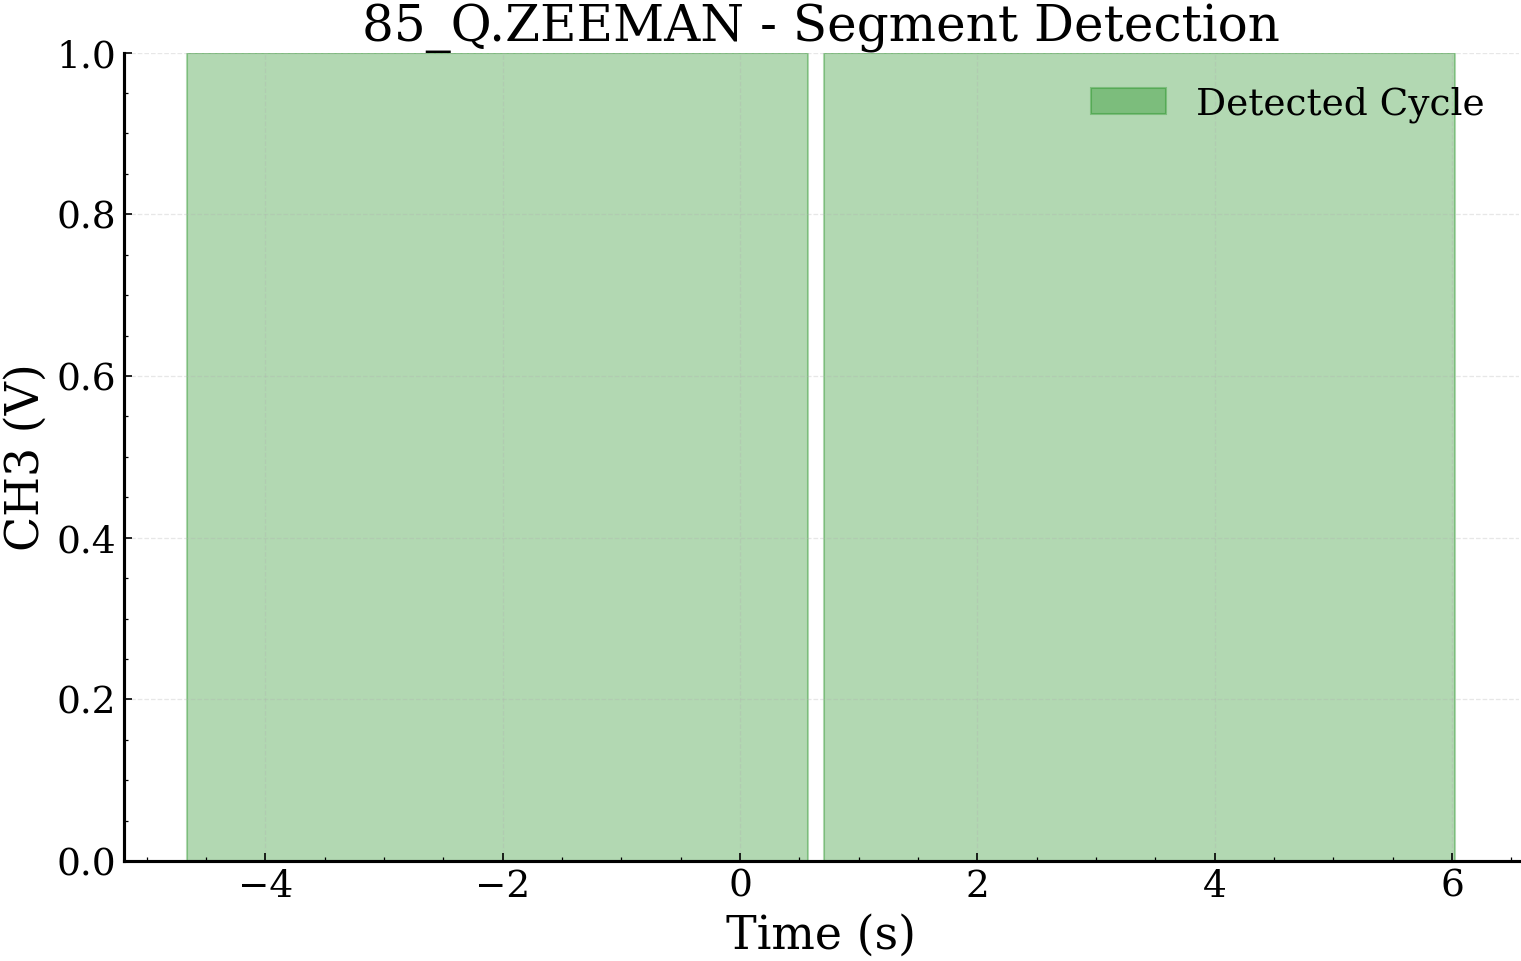

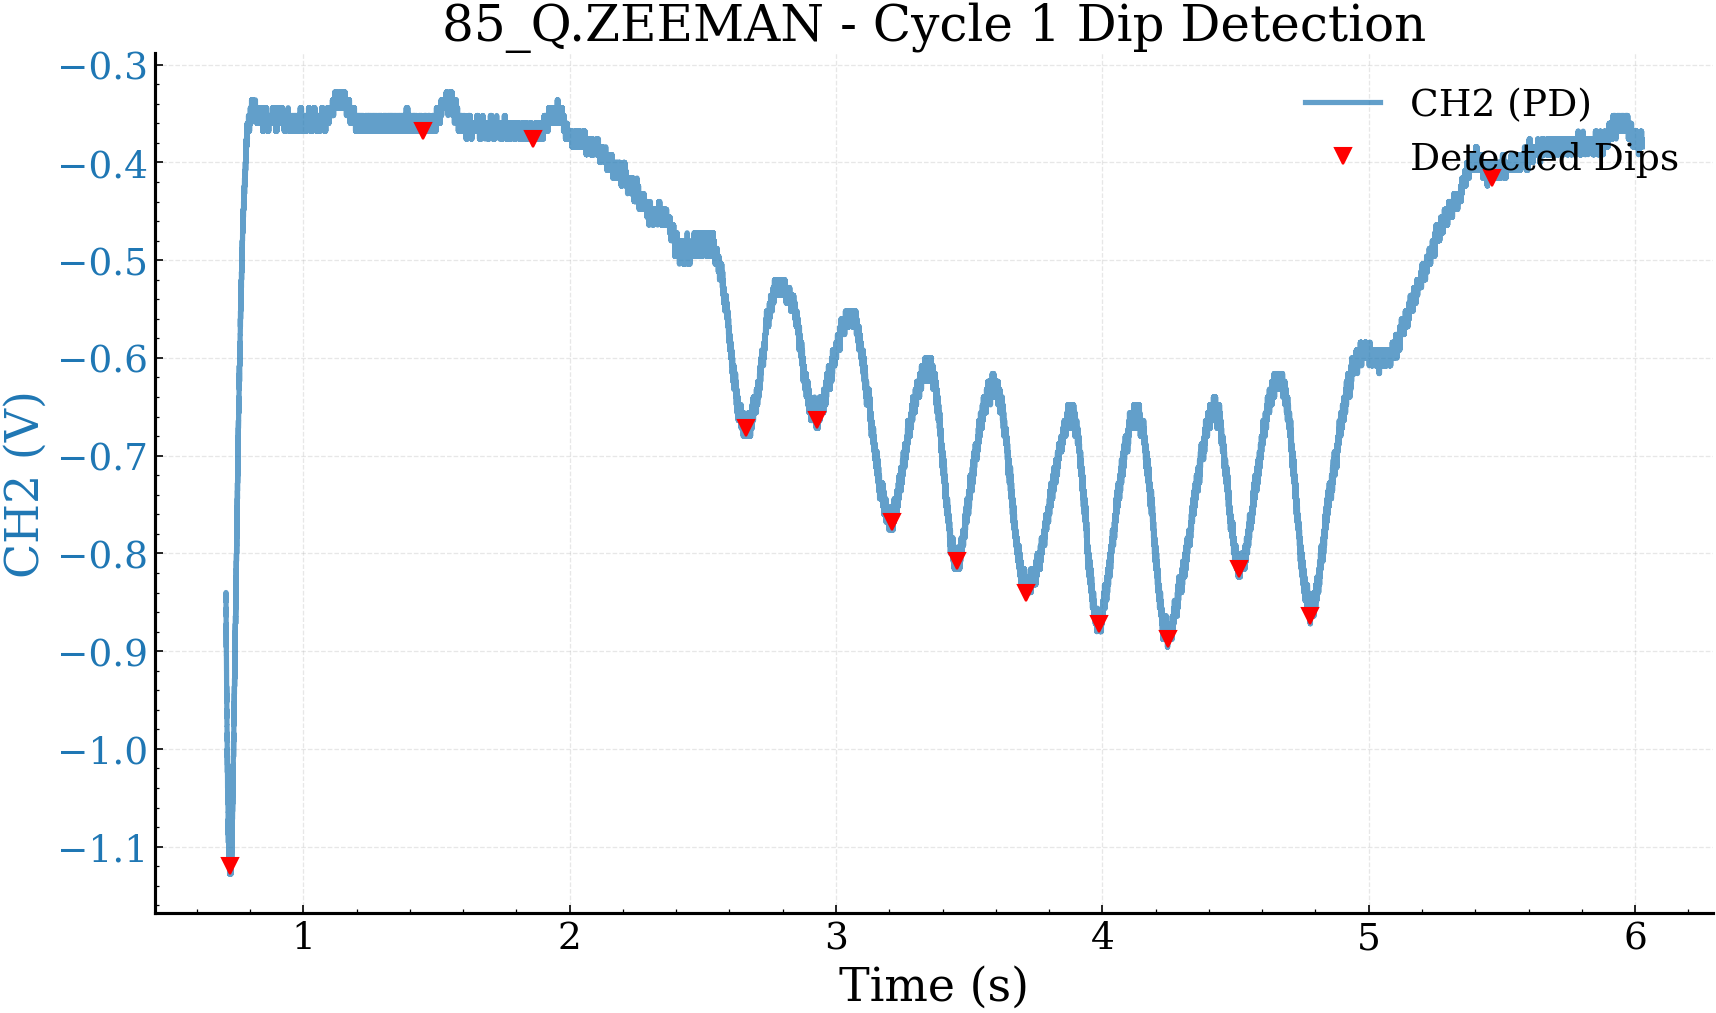

/var/folders/5d/w4l2y8995js1b535ll7mb0hr0000gn/T/ipykernel_31856/1201778562.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


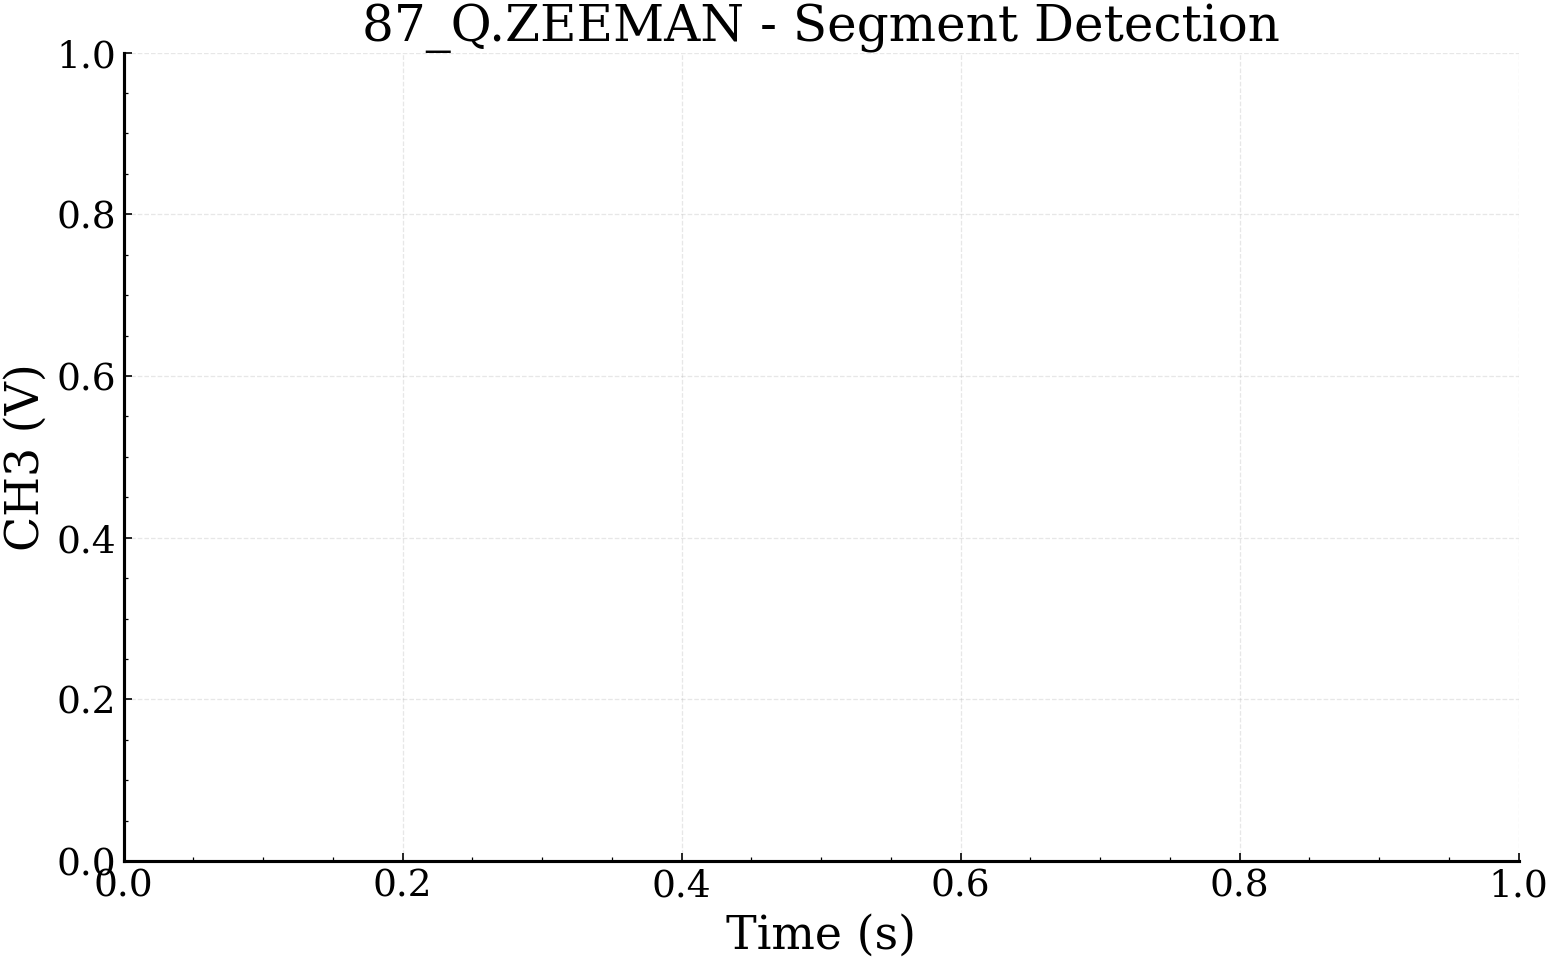

[87_Q.ZEEMAN] Forcing manual single cycle extraction across the main slope...


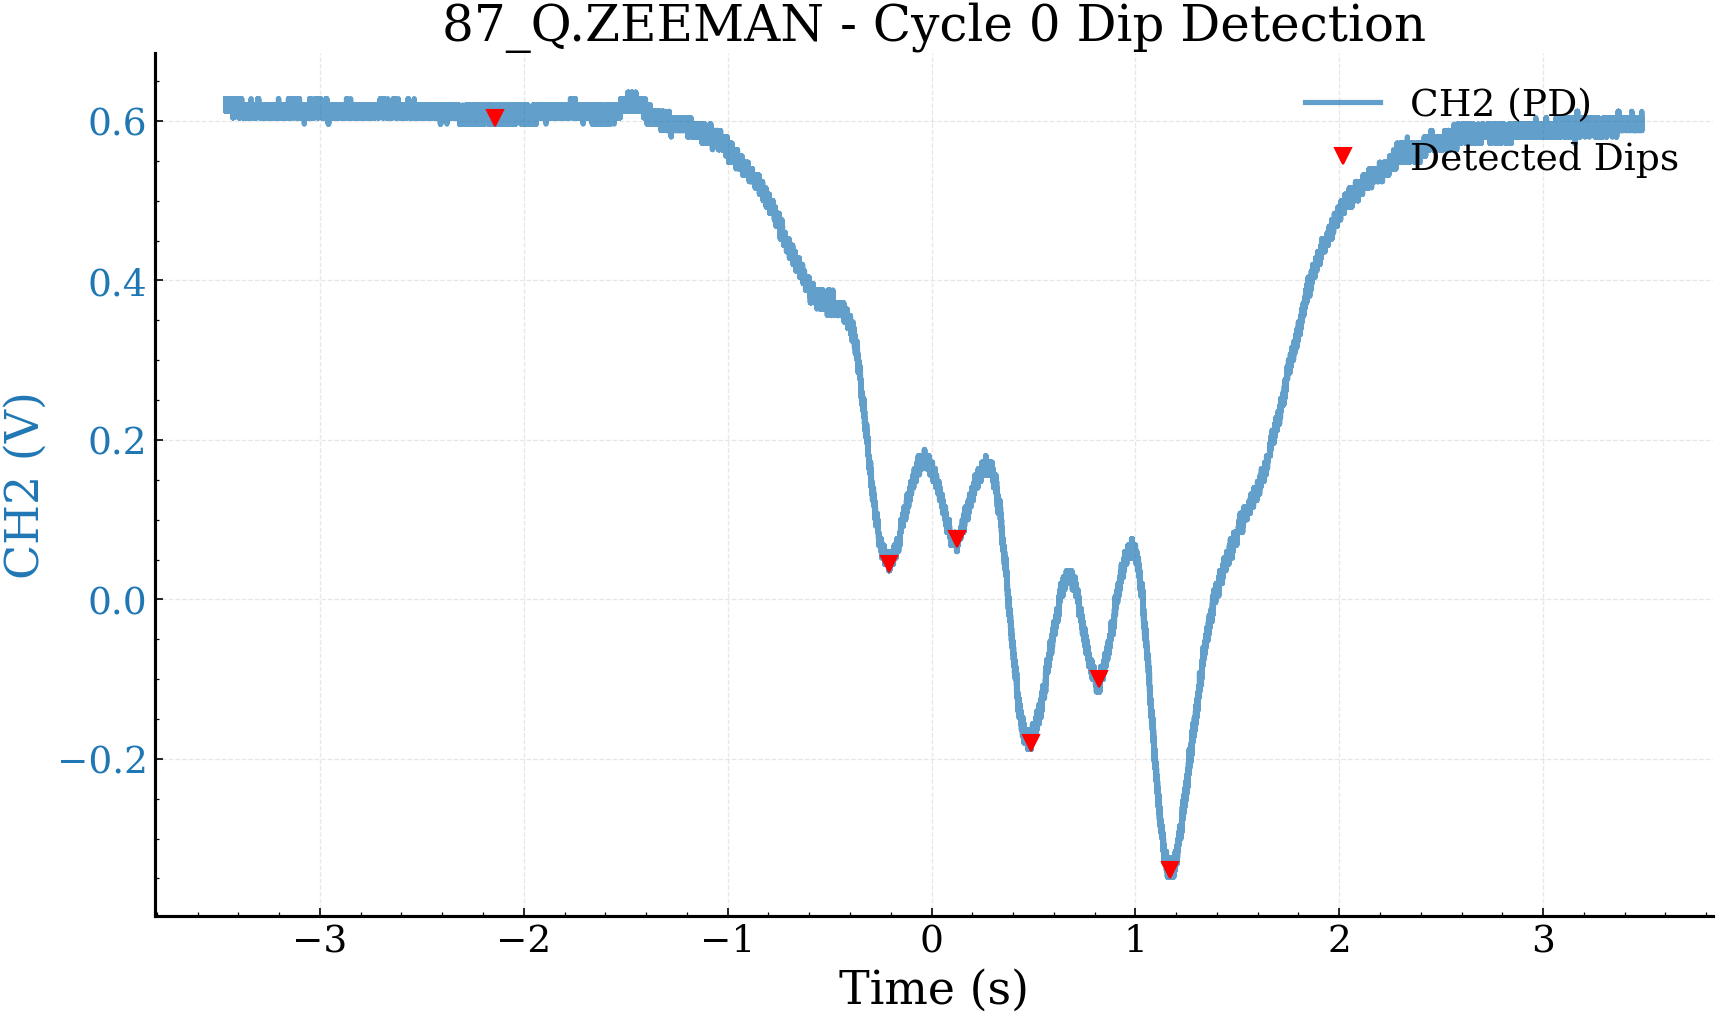

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.signal.segmentation import extract_valid_cycles
from src.signal.detection import detect_dips
from src.visualization.plot_settings import apply_plot_style, save_figure

apply_plot_style("ppt_bw")

# 設定兩個 CSV 檔案的路徑
files = {
    "85_Q.ZEEMAN": "../data/raw/D2_Optical_Pumping/0413/85_Q.ZEEMAN.csv",
    "87_Q.ZEEMAN": "../data/raw/D2_Optical_Pumping/0413/87_Q.ZEEMAN.csv",
}

for label, file_path in files.items():
    # 讀取 CSV 檔案，跳過前面的 metadata (共 11 行)
    df = pd.read_csv(file_path, skiprows=12, names=["Second", "CH2", "CH3"])

    # ---- 1. Extract Valid Cycles ----
    time_data = df["Second"].values
    ch3_data = df["CH3"].values
    ch2_data = df["CH2"].values

    # 設定 duration_range=(4.0, 6.0) 因為這組數據的 cycle大約是 5 秒
    ch3_norm, segments = extract_valid_cycles(
        time_data, ch3_data, duration_range=(4.0, 6.0), min_distance_sec=2.0
    )

    # 繪出整段 CH3 與切割的範圍 (即使沒有切出 cycle 也能看見原始斜直線)
    plt.figure(figsize=(12, 7))
    # plt.plot(time_data, ch3_data, label="CH3 (Sweep)", color="tab:orange", alpha=0.8, rasterized=True)

    for i, (st, ed) in enumerate(segments):
        label_str = "Detected Cycle" if i == 0 else ""
        plt.axvspan(
            time_data[st], time_data[ed], color="green", alpha=0.3, label=label_str
        )

    plt.title(f"{label} - Segment Detection")
    plt.xlabel("Time (s)")
    plt.ylabel("CH3 (V)")
    plt.legend(loc="upper right")
    plt.grid(True)
    save_figure(
        plt.gcf(),
        f"4c_segment_detection_{label}_ppt_bw.pdf",
        directory="../reports/figures",
    )
    plt.show()

    if label == "87_Q.ZEEMAN" or len(segments) == 0:
        print(
            f"[{label}] Forcing manual single cycle extraction across the main slope..."
        )
        start_idx = int(np.argmin(ch3_data))
        end_idx = int(np.argmax(ch3_data))
        if start_idx > end_idx:
            start_idx, end_idx = end_idx, start_idx
        segments = [(start_idx, end_idx)]

    # 如果有超過 5 個 cycle，就選第 5 個（index 5），否則就選能用的最後一個
    cycle_idx = min(5, len(segments) - 1)
    start_idx, end_idx = segments[cycle_idx]

    t_seg = time_data[start_idx : end_idx + 1]
    ch2_seg = ch2_data[start_idx : end_idx + 1]
    ch3_seg = ch3_data[start_idx : end_idx + 1]

    # ---- 2. Detect Dips for this cycle ----
    dips_df = detect_dips(
        time_data,
        ch2_data,
        ch3_norm,
        [segments[cycle_idx]],
        prominence=0.02,
        min_dip_sep=0.02,
        smooth_pts=501,
    )

    # ---- 3. Visualization ----
    fig, ax1 = plt.subplots(figsize=(12, 7))

    color = "tab:blue"
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("CH2 (V)", color=color)
    ax1.plot(t_seg, ch2_seg, color=color, alpha=0.7, label="CH2 (PD)", rasterized=True)

    if not dips_df.empty:
        # 將相對時間換算成陣列的 index (使用 np.round 避免浮點數誤差)
        dt = time_data[1] - time_data[0]
        dip_indices = start_idx + np.round(dips_df["Relative_Time"].values / dt).astype(
            int
        )

        ax1.plot(
            time_data[dip_indices],
            ch2_data[dip_indices],
            "rv",
            markersize=8,
            label="Detected Dips",
        )

    ax1.tick_params(axis="y", labelcolor=color)

    # ax2 = ax1.twinx()
    # color = "tab:red"
    # ax2.set_ylabel("CH3 Sweep Field (V)", color=color)
    # ax2.plot(
    #     t_seg, ch3_seg, color=color, linestyle="--", alpha=0.7, label="CH3 (Sweep)"
    # )
    # ax2.tick_params(axis="y", labelcolor=color)

    fig.tight_layout()
    plt.title(f"{label} - Cycle {cycle_idx} Dip Detection")
    fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)
    plt.grid(True)
    save_figure(
        fig, f"4c_dip_detection_{label}_ppt_bw.pdf", directory="../reports/figures"
    )
    plt.show()

/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


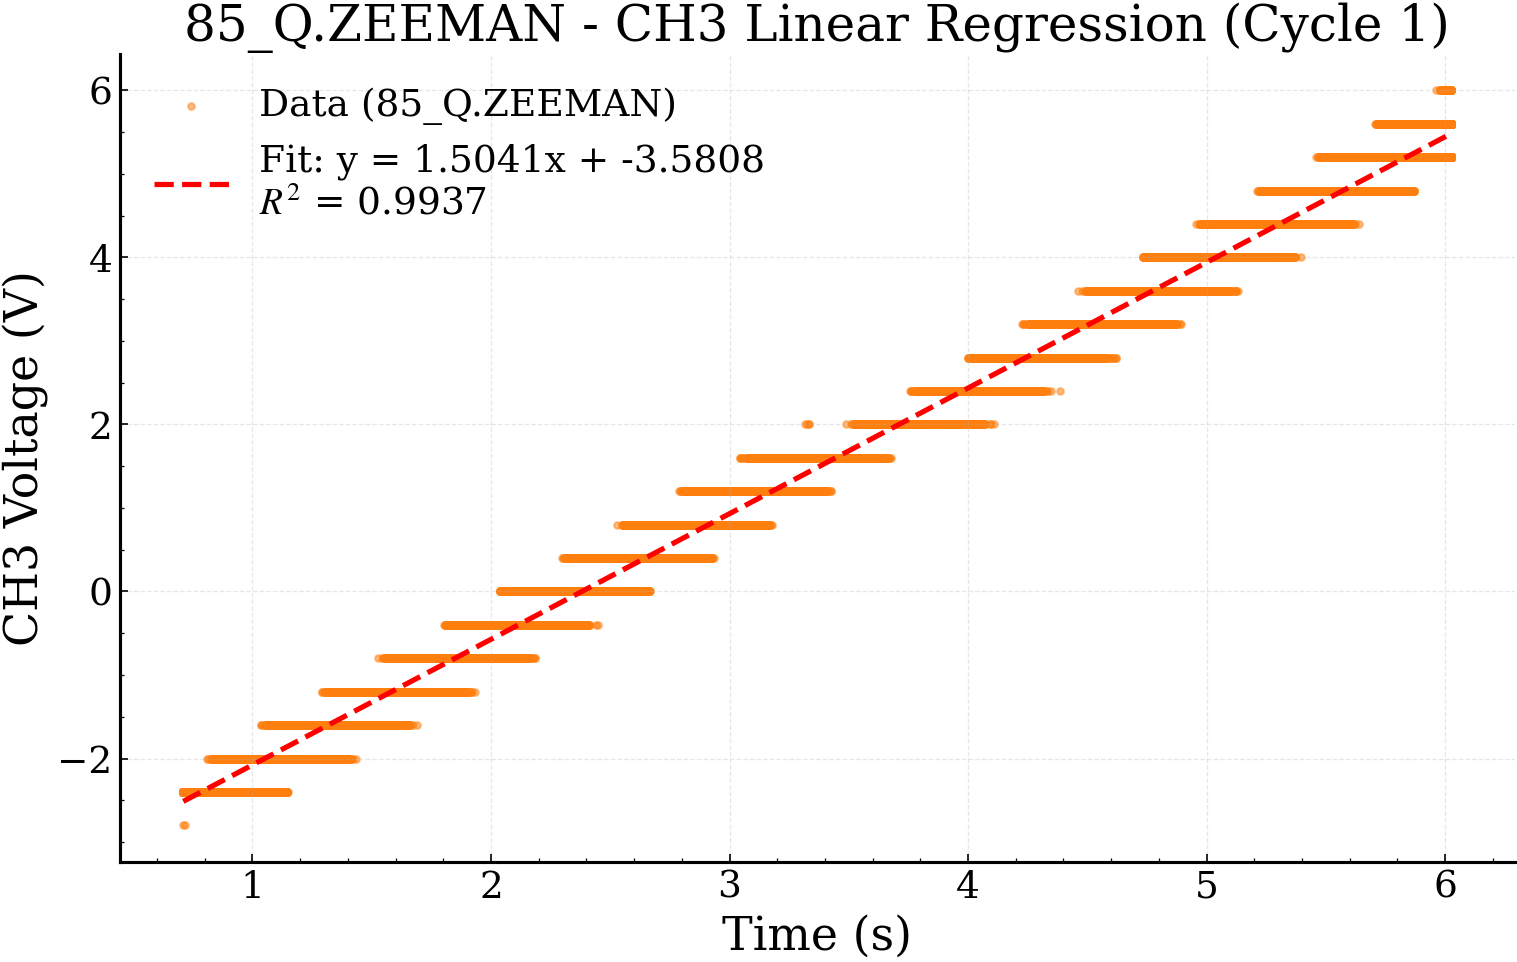

[85_Q.ZEEMAN] Cycle 1 線性回歸結果:
  Slope (斜率) = 1.504140289504562+/-0 V/s
  Intercept (截距) = -3.5807673152020616+/-0 V
  R-squared = 0.99367



/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/Users/dengensheng/Developer/D2_Optical_Pumping/src/visualization/plot_settings.py:366: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(path)
/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


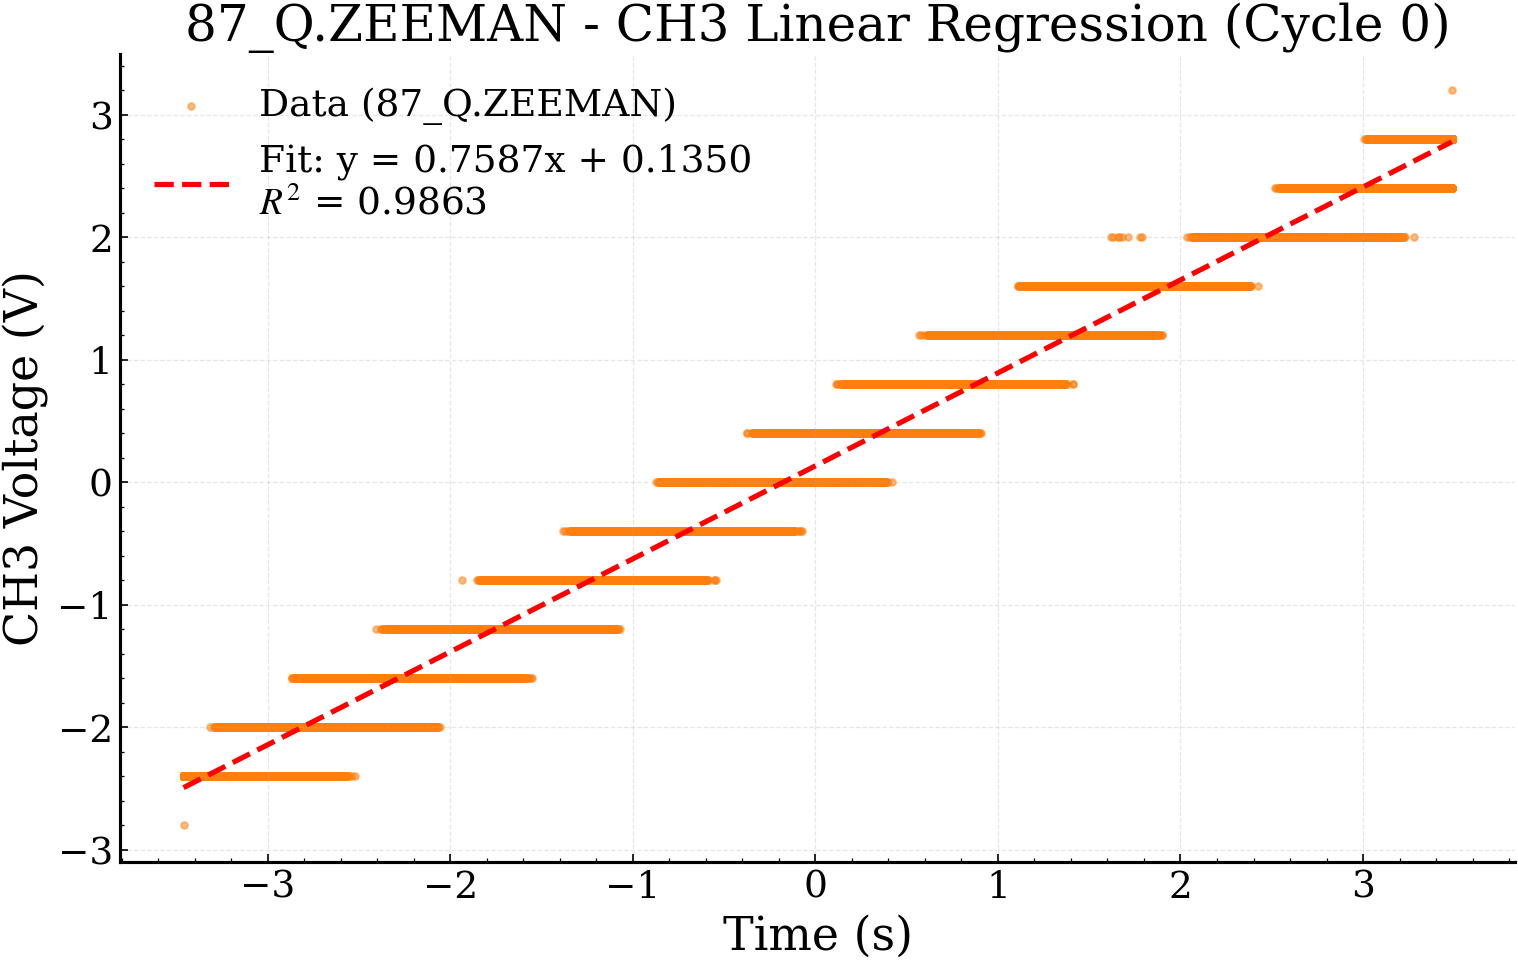

[87_Q.ZEEMAN] Cycle 0 線性回歸結果:
  Slope (斜率) = 0.7586586205238112+/-0 V/s
  Intercept (截距) = 0.13497956197330804+/-0 V
  R-squared = 0.98634



In [3]:
from src.analysis.fitting import excel_style_regression_with_propagation
from src.visualization.plot_settings import apply_plot_style, save_figure

# 對 85_Q 與 87_Q 各自的 cycle 做線性回歸並畫圖
files = {
    "85_Q.ZEEMAN": "../data/raw/D2_Optical_Pumping/0413/85_Q.ZEEMAN.csv",
    "87_Q.ZEEMAN": "../data/raw/D2_Optical_Pumping/0413/87_Q.ZEEMAN.csv",
}

apply_plot_style("ppt_bw")

for label, file_path in files.items():
    df = pd.read_csv(file_path, skiprows=12, names=["Second", "CH2", "CH3"])
    time_data = df["Second"].values
    ch3_data = df["CH3"].values

    # 和上方一樣的邏輯切分 cycles
    # 設定 duration_range=(4.0, 6.0) 因為這組數據的 cycle大約是 5 秒
    ch3_norm, segments = extract_valid_cycles(
        time_data, ch3_data, duration_range=(4.0, 6.0), min_distance_sec=2.0
    )

    # 決定使用的 cycle (依照上面邏輯)
    if label == "87_Q.ZEEMAN" or len(segments) == 0:
        start_idx = int(np.argmin(ch3_data))
        end_idx = int(np.argmax(ch3_data))
        if start_idx > end_idx:
            start_idx, end_idx = end_idx, start_idx
        segments = [(start_idx, end_idx)]

    cycle_idx = min(5, len(segments) - 1)
    start_idx, end_idx = segments[cycle_idx]

    t_seg = time_data[start_idx : end_idx + 1]
    ch3_seg = ch3_data[start_idx : end_idx + 1]

    # 線性回歸
    sigma_t = np.zeros_like(t_seg)
    sigma_ch3 = np.zeros_like(ch3_seg)
    slope, intercept = excel_style_regression_with_propagation(
        t_seg, ch3_seg, sigma_t, sigma_ch3
    )

    fit_line = intercept.nominal_value + slope.nominal_value * t_seg

    # 手動計算 R-squared
    ss_res = np.sum((ch3_seg - fit_line) ** 2)
    ss_tot = np.sum((ch3_seg - np.mean(ch3_seg)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)

    # 繪圖
    fig = plt.figure(figsize=(12, 7))
    plt.scatter(
        t_seg,
        ch3_seg,
        label=f"Data ({label})",
        color="tab:orange",
        s=10,
        alpha=0.5,
        rasterized=True,
    )
    plt.plot(
        t_seg,
        fit_line,
        color="red",
        linestyle="--",
        label=f"Fit: y = {slope.nominal_value:.4f}x + {intercept.nominal_value:.4f}\n$R^2$ = {r_squared:.4f}",
    )

    plt.title(f"{label} - CH3 Linear Regression (Cycle {cycle_idx})")
    plt.xlabel("Time (s)")
    plt.ylabel("CH3 Voltage (V)")
    plt.legend()
    plt.grid(True)

    save_figure(
        fig,
        f"4c_ch3_linear_regression_{label}_ppt_bw.pdf",
        directory="../reports/figures",
    )
    plt.show()

    # 印出回歸結果
    print(f"[{label}] Cycle {cycle_idx} 線性回歸結果:")
    print(f"  Slope (斜率) = {slope} V/s")
    print(f"  Intercept (截距) = {intercept} V")
    print(f"  R-squared = {r_squared:.5f}\n")

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
from scipy.signal import find_peaks
from scipy.optimize import root
from uncertainties import ufloat

sys.path.append(os.path.abspath(".."))
from src.analysis.fitting import excel_style_regression_with_propagation
from src.visualization.plot_settings import apply_plot_style, save_figure

# Physical constants
mu_b = 9.274009994e-28  # J/G
h = 6.62607015e-34  # J.s
mu_N = 5.050783699e-27  # J/T = 5.050783699e-31 J/G

# Isotope properties
# Rb-87: I=3/2, g_I = -0.000995, g_J = 2.002331, delta_W = h * 6.83468261GHz
# Rb-85: I=5/2, g_I = -0.000293, g_J = 2.002331, delta_W = h * 3.03573244GHz
# From https://steck.us/alkalidata/rubidium87numbers.pdf
properties = {
    "Rb-87": {
        "I": 1.5,
        "g_I": -0.0009951414,
        "g_J": 2.00233113,
        "delta_nu": 6.8346826109e9,  # Hz
        "nu_RF": 4.9874e6,  # Hz
        "M_vals": [
            -1,
            0,
            1,
        ],  # F=2 to F=2 transitions M=-2 to -1, -1 to 0, 0 to 1, 1 to 2 -> Wait, actually F=2 M transitions are 4, F=1 M transitions are 2
    },
    "Rb-85": {
        "I": 2.5,
        "g_I": -0.00029364,
        "g_J": 2.00233113,
        "delta_nu": 3.035732439e9,  # Hz
        "nu_RF": 3.3391e6,  # Hz
    },
}

In [5]:
import pandas as pd
from uncertainties import ufloat

# 讀取剛剛從 4b 匯出的 calibration.csv
df_calib = pd.read_csv("../data/interim/calibration.csv").set_index("parameter")

# 重新建立 ufloat 物件以保有不確定度
slope_B = ufloat(df_calib.loc["slope_B", "nominal"], df_calib.loc["slope_B", "std_dev"])
intercept_B = ufloat(
    df_calib.loc["intercept_B", "nominal"], df_calib.loc["intercept_B", "std_dev"]
)

slope_main = ufloat(
    df_calib.loc["slope_main", "nominal"], df_calib.loc["slope_main", "std_dev"]
)
intercept_main = ufloat(
    df_calib.loc["intercept_main", "nominal"], df_calib.loc["intercept_main", "std_dev"]
)

print("--- Loaded from calibration.csv ---")
print(f"Sweep Field: slope = {slope_B}, intercept = {intercept_B}")
print(f"Main Field: slope = {slope_main}, intercept = {intercept_main}")

--- Loaded from calibration.csv ---
Sweep Field: slope = 0.640+/-0.004, intercept = -0.2263+/-0.0024
Main Field: slope = 8.579+/-0.024, intercept = 0.0059+/-0.0022


In [6]:
def W(F, M, x, delta_W, I_spin, mu_I, B):
    term1 = -delta_W / (2 * (2 * I_spin + 1))
    term2 = -(mu_I / I_spin) * B * M

    # Square root term \pm \frac{\Delta W}{2} [1 + \frac{4Mx}{2I+1} + x^2]^{1/2}
    sqrt_inner = 1 + (4 * M * x) / (2 * I_spin + 1) + x**2
    term3 = (delta_W / 2) * np.sqrt(sqrt_inner)

    if F == I_spin + 0.5:
        return term1 + term2 + term3
    elif F == I_spin - 0.5:
        return term1 + term2 - term3
    else:
        raise ValueError("Invalid F")


def transition_freq(B_gauss, I_spin, F, M_initial, M_final, g_J, g_I, delta_nu):
    delta_W = h * delta_nu
    # x = (g_J - g_I) * mu_0 * B / \Delta W (Wait, mu_0 is mu_b here J/G)
    x = (g_J - g_I) * mu_b * B_gauss / delta_W
    mu_I_val = (
        -g_I * I_spin * mu_b
    )  # mu_I / (I) = -g_I * mu_b => mu_I = -g_I * I * mu_b

    W_f = W(F, M_final, x, delta_W, I_spin, mu_I_val, B_gauss)
    W_i = W(F, M_initial, x, delta_W, I_spin, mu_I_val, B_gauss)

    return float(abs(W_f - W_i)) / h


def solve_resonance_B(
    nu_RF, I_spin, F, M_initial, M_final, g_J, g_I, delta_nu, guess=7.1
):
    obj = (
        lambda B: transition_freq(B, I_spin, F, M_initial, M_final, g_J, g_I, delta_nu)
        - nu_RF
    )
    from scipy.optimize import root_scalar

    res = root_scalar(
        obj, bracket=[0.01, 100], method="brentq"
    )  # Bracket from 0.01G to 100G
    return res.root


theoretical_transitions = {}

for iso, props in properties.items():
    I_val = props["I"]
    F_upper = I_val + 0.5
    F_lower = I_val - 0.5

    B_theory = []

    # F upper transitions
    for M in np.arange(-F_upper, F_upper):
        B_res = solve_resonance_B(
            props["nu_RF"],
            I_val,
            F_upper,
            M,
            M + 1,
            props["g_J"],
            props["g_I"],
            props["delta_nu"],
        )
        B_theory.append(
            {"F": F_upper, "M_initial": int(M), "M_final": int(M + 1), "B_pred": B_res}
        )

    # F lower transitions
    for M in np.arange(-F_lower, F_lower):
        B_res = solve_resonance_B(
            props["nu_RF"],
            I_val,
            F_lower,
            M,
            M + 1,
            props["g_J"],
            props["g_I"],
            props["delta_nu"],
        )
        B_theory.append(
            {"F": F_lower, "M_initial": int(M), "M_final": int(M + 1), "B_pred": B_res}
        )

    theoretical_transitions[iso] = (
        pd.DataFrame(B_theory).sort_values("B_pred").reset_index(drop=True)
    )
    print(f"--- Theoretical {iso} ---")
    print(theoretical_transitions[iso])

--- Theoretical Rb-87 ---
     F  M_initial  M_final    B_pred
0  1.0         -1        0  7.095695
1  1.0          0        1  7.106018
2  2.0         -2       -1  7.113478
3  2.0         -1        0  7.123909
4  2.0          0        1  7.134355
5  2.0          1        2  7.144816
--- Theoretical Rb-85 ---
     F  M_initial  M_final    B_pred
0  3.0         -3       -2  7.114892
1  2.0         -2       -1  7.118135
2  3.0         -2       -1  7.130589
3  2.0         -1        0  7.133784
4  3.0         -1        0  7.146320
5  2.0          0        1  7.149467
6  3.0          0        1  7.162087
7  2.0          1        2  7.165185
8  3.0          1        2  7.177888
9  3.0          2        3  7.193724


Experimental Base Main Field: 7.0404 Gauss


/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


[Rb-85] Optimized Sweep Current Range: 0.3672 A to 0.6275 A


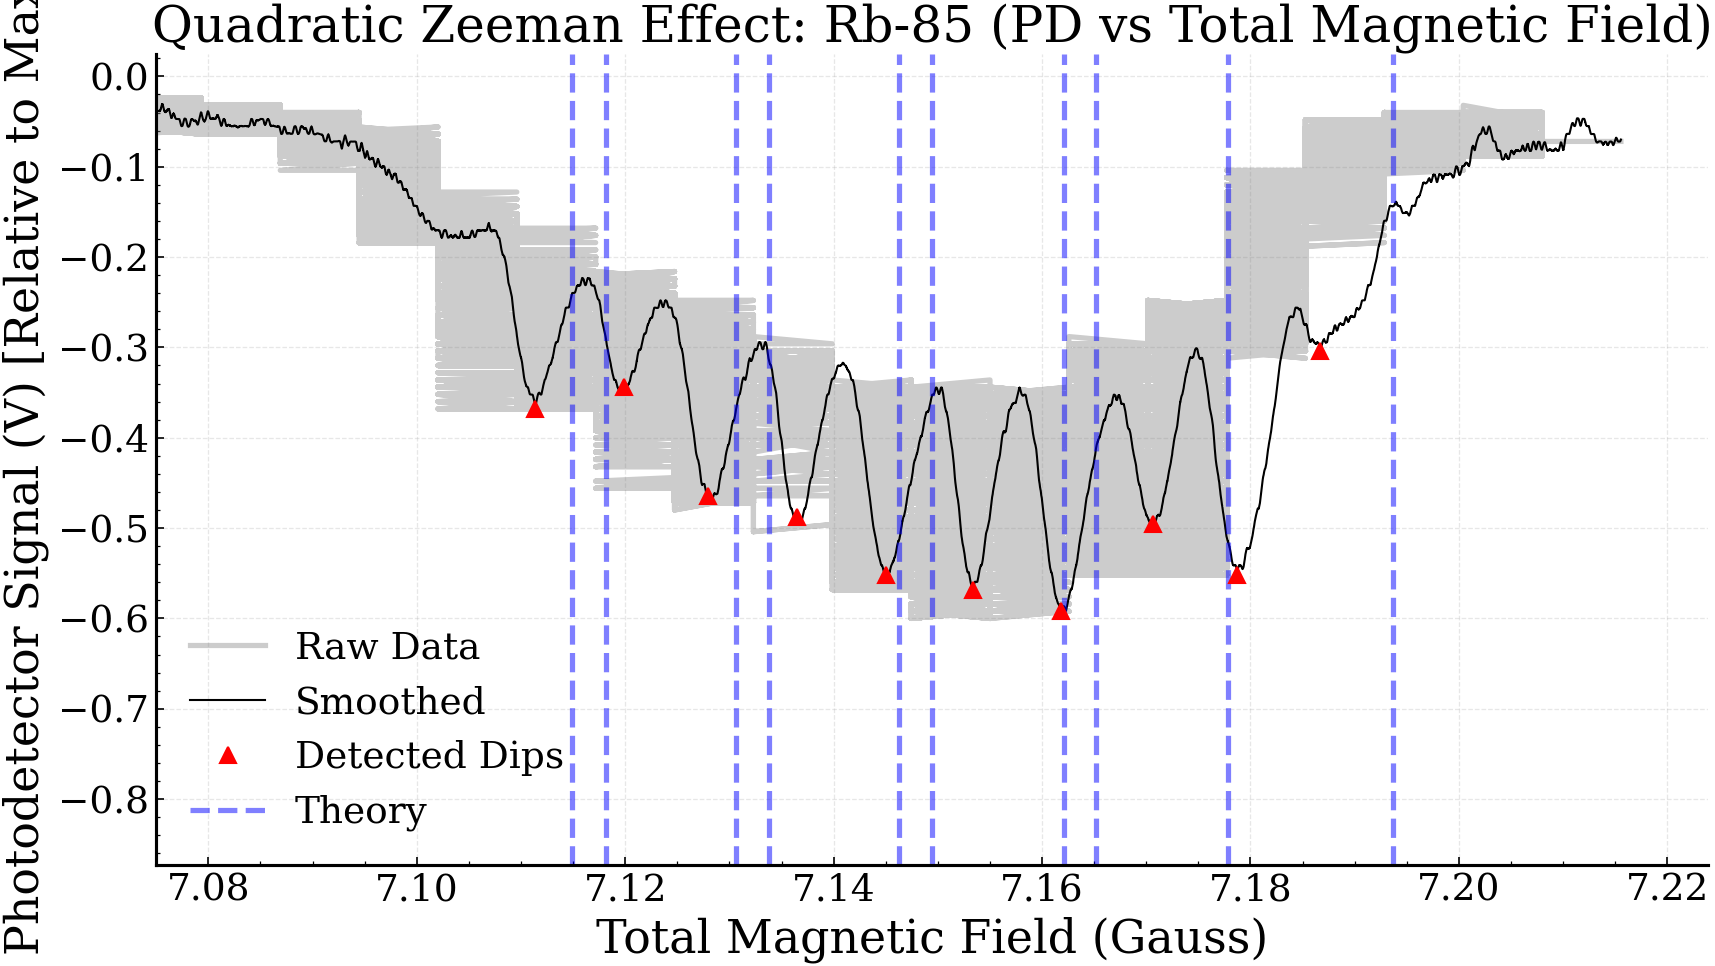

[Rb-87] Forcing manual cycle extraction across the main slope...


/Users/dengensheng/Developer/D2_Optical_Pumping/.venv/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


[Rb-87] Hardcoded Sweep Current Range: 0.3096 A to 0.6191 A


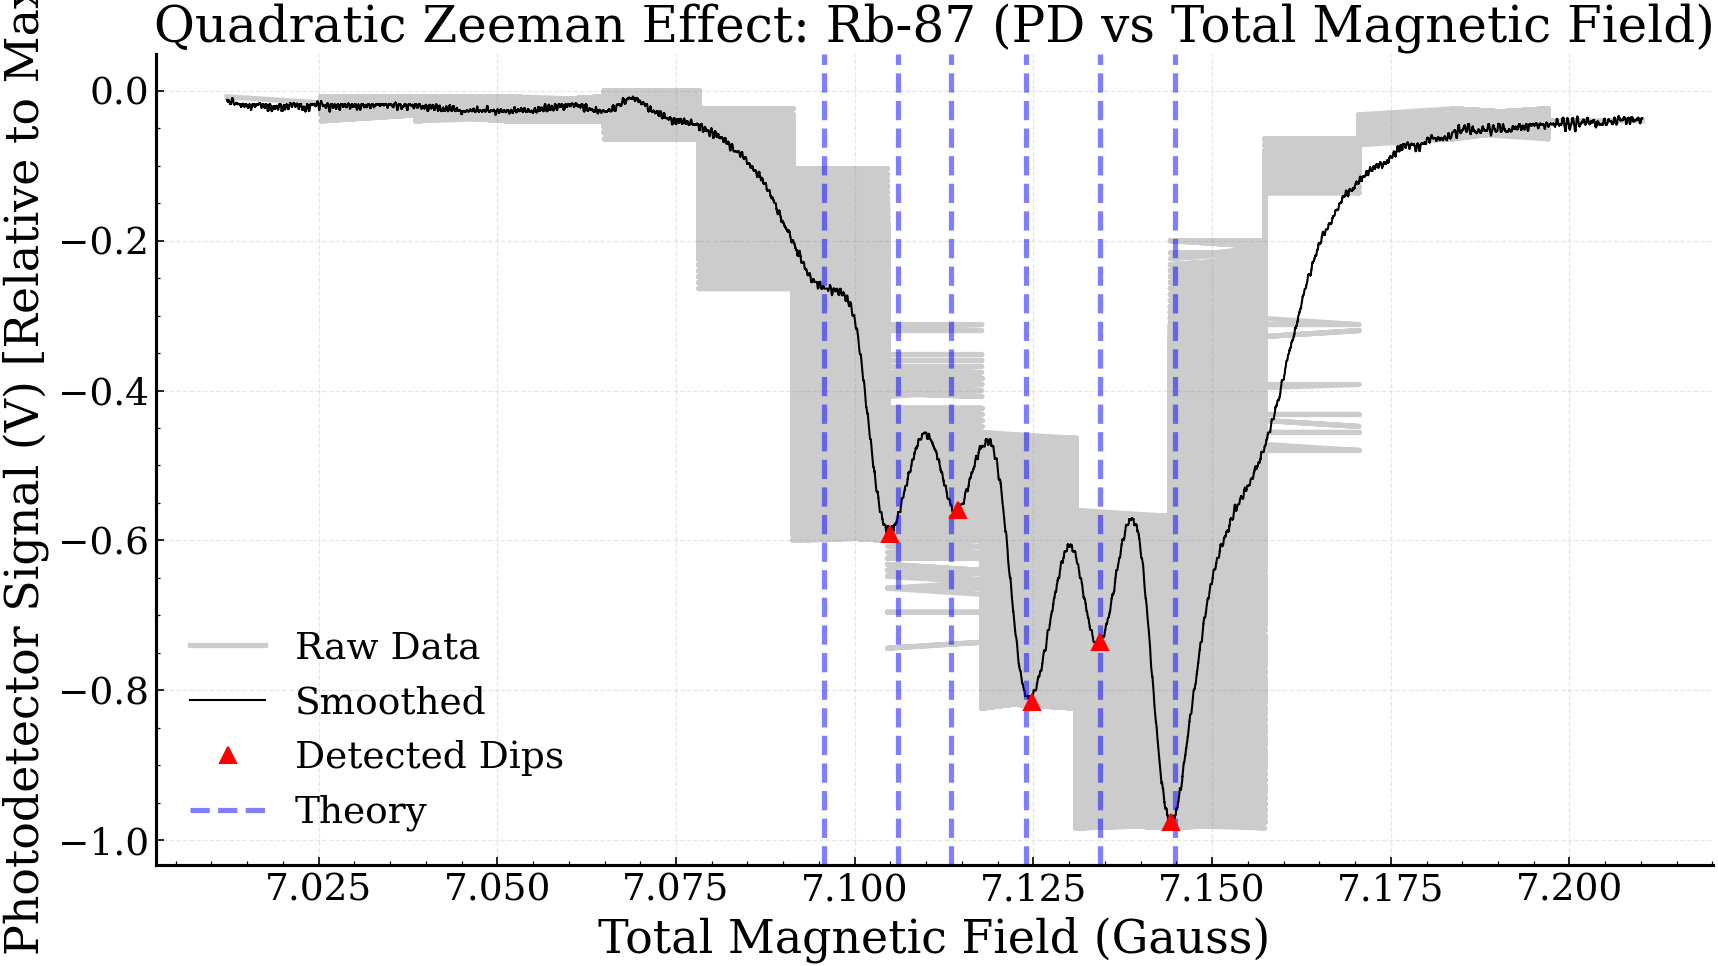

Saved extracted dips to ../data/interim/4c.csv


,Isotope,F,M_i,M_f,B_meas (Gauss),B_theory (Gauss),Error (%),Diff (Gauss)
0,Rb-85,3.000000,-3.000000,-2.000000,7.1114,7.1149,-0.049,-0.0035
1,Rb-85,2.000000,-2.000000,-1.000000,7.1199,7.1181,0.025,0.0018
2,Rb-85,3.000000,-2.000000,-1.000000,7.1280,7.1306,-0.037,-0.0026
3,Rb-85,2.000000,-1.000000,0.000000,7.1365,7.1338,0.038,0.0027
4,Rb-85,3.000000,-1.000000,0.000000,7.1450,7.1463,-0.018,-0.0013
5,Rb-85,2.000000,0.000000,1.000000,7.1533,7.1495,0.054,0.0039
6,Rb-85,3.000000,0.000000,1.000000,7.1618,7.1621,-0.003,-0.0002
7,Rb-85,2.000000,1.000000,2.000000,7.1707,7.1652,0.077,0.0055
8,Rb-85,3.000000,1.000000,2.000000,7.1787,7.1779,0.012,0.0008
9,Rb-85,3.000000,2.000000,3.000000,7.1867,7.1937,-0.097,-0.0070


In [7]:
from src.signal.detection import detect_dips
from src.analysis.fitting import excel_style_regression_with_propagation
from scipy.optimize import minimize

files = {
    "Rb-85": "../data/raw/D2_Optical_Pumping/0413/85_Q.ZEEMAN.csv",
    "Rb-87": "../data/raw/D2_Optical_Pumping/0413/87_Q.ZEEMAN.csv",
}

# The main field is at 0.820 A.
I_main_exp = 0.820
B_main_exp = slope_main.nominal_value * I_main_exp + intercept_main.nominal_value
print(f"Experimental Base Main Field: {B_main_exp:.4f} Gauss")

results = []
csv_export_list = []  # 用來收集寫入 4c.csv 的資料

apply_plot_style("ppt_bw")

for idx, (label, file_path) in enumerate(files.items()):
    fig, ax = plt.subplots(figsize=(12, 7))

    # Read the data
    df = pd.read_csv(file_path, skiprows=11)
    df.columns = ["Second", "CH2", "CH3"]
    t = df["Second"].values

    sweep_field_data = df["CH3"].values
    pd_signal = df["CH2"].values

    # 將最高點設為 0V (相對高度)
    pd_signal = pd_signal - np.max(pd_signal)

    # ---- 2. Find rising segment of the sweep ----
    from src.signal.segmentation import extract_valid_cycles

    # 由於 85_Q / 87_Q 的週期大概是 5 秒，使用新的 duration_range 和 min_distance_sec
    _, valid_segments = extract_valid_cycles(
        t, sweep_field_data, duration_range=(4.0, 6.0), min_distance_sec=2.0
    )

    if label == "Rb-87" or len(valid_segments) == 0:
        print(f"[{label}] Forcing manual cycle extraction across the main slope...")
        start_idx = int(np.argmin(sweep_field_data))
        end_idx = int(np.argmax(sweep_field_data))
        if start_idx > end_idx:
            start_idx, end_idx = end_idx, start_idx
        segments = [(start_idx, end_idx)]
    else:
        # 只取第一個有效 cycle 進行計算，避免跨越多個週期的狀況
        segments = [valid_segments[0]]
        start_idx, end_idx = segments[0]

    # 進行線性回歸來預測 CH3 值
    t_seg = t[start_idx : end_idx + 1]
    ch3_seg = sweep_field_data[start_idx : end_idx + 1]

    # 假設 x 和 y 的測量不確定度為 0 (或非常小)
    sigma_t = np.zeros_like(t_seg)
    sigma_ch3 = np.zeros_like(ch3_seg)

    # 使用 excel_style_regression_with_propagation，注意它只回傳 slope 和 intercept 兩個值
    slope_ch3, intercept_ch3 = excel_style_regression_with_propagation(
        t_seg, ch3_seg, sigma_t, sigma_ch3
    )

    # 用回歸出的直線來取代原本量測的 CH3，以獲得更精確平滑的 sweep current (CH3)
    sweep_field_predicted = slope_ch3.nominal_value * t + intercept_ch3.nominal_value

    ch3_min, ch3_max = (
        sweep_field_predicted[start_idx : end_idx + 1].min(),
        sweep_field_predicted[start_idx : end_idx + 1].max(),
    )

    # ---- 尋找最佳的 I_min 與 I_max 來對齊理論磁場 ----
    B_theory_list = theoretical_transitions[label]["B_pred"].values

    def optimize_ch3_range(params):
        I_min, I_max = params
        test_ch3_norm = (sweep_field_predicted - ch3_min) / (ch3_max - ch3_min) * (
            I_max - I_min
        ) + I_min

        # 重新偵測
        test_min_dip_sep = 0.05 if label == "Rb-87" else 0.03
        test_prominence = 0.02

        try:
            dips_df_test = detect_dips(
                t,
                pd_signal,
                test_ch3_norm,
                segments,
                prominence=test_prominence,
                min_dip_sep=test_min_dip_sep,
                smooth_pts=501,
            )
        except:
            return 1e6

        if len(dips_df_test) > 0:
            # 加入高度過濾條件
            dt_test = t[1] - t[0]
            dip_indices_test = start_idx + np.round(
                dips_df_test["Relative_Time"].values / dt_test
            ).astype(int)
            dip_heights = pd_signal[dip_indices_test]
            threshold = -0.1 if label == "Rb-85" else -0.1
            valid_mask = dip_heights <= threshold
            dips_df_test = dips_df_test[valid_mask]

            if label == "Rb-85" and len(dips_df_test) > 10:
                # 忽略最前面的 Detected Dip 以專心 fit 10個 Theory 和 10個 Detected Dips
                dips_df_test = dips_df_test.sort_values("Relative_Time").iloc[1:]

        if len(dips_df_test) == 0:
            return 1e6

        test_B_meas = B_main_exp + (
            slope_B.nominal_value * dips_df_test["CH3_Voltage"].values
            + intercept_B.nominal_value
        )

        b_theory_fit = B_theory_list.copy()
        if label == "Rb-87":
            # 依照指示，忽略 Rb-87 中理論值最小的那個 dip
            b_theory_fit = b_theory_fit[b_theory_fit != np.min(b_theory_fit)]

        total_error = 0
        b_th_copy = np.copy(b_theory_fit)

        # 改為逐一將測量值去配對剩下的理論值，確保 5 對 5 能夠穩定計算
        for b_meas in test_B_meas:
            if len(b_th_copy) == 0:
                total_error += 10  # 沒配對到的懲罰
                continue
            diffs = np.abs(b_th_copy - b_meas)
            closest_idx = np.argmin(diffs)
            total_error += diffs[closest_idx] ** 2
            b_th_copy = np.delete(b_th_copy, closest_idx)

        return total_error

    # 初始值給 [0.3, 0.6] 作為猜測
    if label == "Rb-87":
        I_min_opt, I_max_opt = 0.3096, 0.6191
        print(
            f"[{label}] Hardcoded Sweep Current Range: {I_min_opt:.4f} A to {I_max_opt:.4f} A"
        )
    else:
        res = minimize(optimize_ch3_range, [0.3, 0.6], bounds=[(0.0, 1.0), (0.1, 1.5)])
        I_min_opt, I_max_opt = res.x
        print(
            f"[{label}] Optimized Sweep Current Range: {I_min_opt:.4f} A to {I_max_opt:.4f} A"
        )

    # 使用最佳化後的 I_min 與 I_max
    ch3_norm = (sweep_field_predicted - ch3_min) / (ch3_max - ch3_min) * (
        I_max_opt - I_min_opt
    ) + I_min_opt

    # 計算整條曲線上對應的 Total B field
    B_total_continuous = B_main_exp + (
        slope_B.nominal_value * ch3_norm + intercept_B.nominal_value
    )

    # 針對原始測量數據的 X 軸 (Raw Data 用的 Total B Field)
    ch3_norm_raw = (
        sweep_field_data - sweep_field_data[start_idx : end_idx + 1].min()
    ) / (
        sweep_field_data[start_idx : end_idx + 1].max()
        - sweep_field_data[start_idx : end_idx + 1].min()
    ) * (
        I_max_opt - I_min_opt
    ) + I_min_opt
    B_total_raw = B_main_exp + (
        slope_B.nominal_value * ch3_norm_raw + intercept_B.nominal_value
    )

    # ---- 3. Detect Dips using 4b logic ----
    min_dip_sep = 0.05 if label == "Rb-87" else 0.03
    prominence = 0.02

    dips_df = detect_dips(
        t,
        pd_signal,
        ch3_norm,
        segments,
        prominence=prominence,
        min_dip_sep=min_dip_sep,
        smooth_pts=501,
    )

    if len(dips_df) > 0:
        # 進行最後的寫入及畫圖前，加入高度過濾條件
        dt_val = t[1] - t[0]
        dip_indices_final = start_idx + np.round(
            dips_df["Relative_Time"].values / dt_val
        ).astype(int)
        dip_heights_final = pd_signal[dip_indices_final]
        threshold = -0.1 if label == "Rb-85" else -0.1
        valid_mask_final = dip_heights_final <= threshold
        dips_df = dips_df[valid_mask_final]

        if label == "Rb-85" and len(dips_df) > 10:
            # 忽略最前面的 Detected Dip 以專心 fit 10個 Theory 和 10個 Detected Dips
            dips_df = dips_df.sort_values("Relative_Time").iloc[1:]

    detected_ch3_norm = np.array([])
    detected_rel_time = np.array([])
    B_total_measured = np.array([])

    if len(dips_df) > 0:
        detected_ch3_norm = dips_df["CH3_Voltage"].values
        detected_rel_time = dips_df["Relative_Time"].values

        B_sweep_measured = (
            slope_B.nominal_value * detected_ch3_norm + intercept_B.nominal_value
        )
        B_total_measured = B_main_exp + B_sweep_measured

        # 收集匯出資料比照 D2.csv 格式
        RF_freq = 3339100 if label == "Rb-85" else 4987400
        for i in range(len(detected_ch3_norm)):
            # 計算對應 index
            curr_idx = start_idx + int(np.round(detected_rel_time[i] / (t[1] - t[0])))
            curr_dip_depth = pd_signal[curr_idx]

            csv_export_list.append(
                {
                    "RF freq.": RF_freq,
                    "main field current": I_main_exp,
                    "main field current uncertainty": 0.0,
                    "time position": detected_rel_time[i],
                    "time uncertainty": 0.0,
                    "CH3 current": detected_ch3_norm[
                        i
                    ],  # 使用了基於線性回歸結果的 CH3 模型預測值
                    "CH3 current uncertainty": 0.0,
                    "dip depth": curr_dip_depth,  # 記錄相對深度的值
                    "tag": label,
                }
            )

    # Plot experimental with B_total on x-axis
    ax.plot(
        B_total_raw[start_idx : end_idx + 1],
        pd_signal[start_idx : end_idx + 1],
        color="gray",
        alpha=0.4,
        label="Raw Data",
        rasterized=True,
    )

    from scipy.ndimage import uniform_filter1d

    pd_smooth = -uniform_filter1d(-pd_signal, size=501)
    # 改畫對預測出總磁場結果的曲線
    ax.plot(
        B_total_continuous[start_idx : end_idx + 1],
        pd_smooth[start_idx : end_idx + 1],
        color="black",
        lw=1.0,
        label="Smoothed",
        rasterized=True,
    )

    if len(detected_rel_time) > 0:
        peaks_indices = start_idx + np.round(detected_rel_time / (t[1] - t[0])).astype(
            int
        )
        ax.plot(
            B_total_continuous[peaks_indices],
            pd_signal[peaks_indices],
            "r^",
            markersize=8,
            label="Detected Dips",
            zorder=3,
        )

    ax.set_title(f"Quadratic Zeeman Effect: {label} (PD vs Total Magnetic Field)")
    ax.set_xlabel("Total Magnetic Field (Gauss)")
    ax.set_ylabel("Photodetector Signal (V) [Relative to Max]")

    if label == "Rb-85":
        ax.set_xlim(left=7.075)

    # Plot Theoretical B as vertical lines
    for b_th in B_theory_list:
        ax.axvline(
            b_th,
            color="blue",
            linestyle="--",
            alpha=0.5,
            label="Theory" if b_th == B_theory_list[0] else "",
        )

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="lower left")

    matched_results = []

    b_th_copy_final = B_theory_list.copy()
    if label == "Rb-87":
        b_th_copy_final = b_th_copy_final[b_th_copy_final != np.min(b_th_copy_final)]
        B_total_measured_copy = B_total_measured.copy()

        # 針對測量點分別去找最接近的理論值 (只找那 5 個)
        for b_meas in B_total_measured_copy:
            if len(b_th_copy_final) == 0:
                continue

            diffs = np.abs(b_th_copy_final - b_meas)
            closest_idx = np.argmin(diffs)
            matched_b_th = b_th_copy_final[closest_idx]

            # 從 original dataframe 找到對應的一列
            row = theoretical_transitions[label][
                np.isclose(theoretical_transitions[label]["B_pred"], matched_b_th)
            ].iloc[0]

            error_percent = (b_meas - matched_b_th) / matched_b_th * 100

            matched_results.append(
                {
                    "Isotope": label,
                    "F": row["F"],
                    "M_i": row["M_initial"],
                    "M_f": row["M_final"],
                    "B_meas (Gauss)": b_meas,
                    "B_theory (Gauss)": matched_b_th,
                    "Error (%)": error_percent,
                    "Diff (Gauss)": b_meas - matched_b_th,
                }
            )
            # 從候選清單中移除，確保不會被重複配對
            b_th_copy_final = np.delete(b_th_copy_final, closest_idx)
    else:
        # Rb-85 照舊
        for i, row in theoretical_transitions[label].iterrows():
            b_th = row["B_pred"]
            if len(B_total_measured) > 0:
                diffs = np.abs(B_total_measured - b_th)
                closest_idx = np.argmin(diffs)
                closest_B_exp = B_total_measured[closest_idx]
                error_percent = (closest_B_exp - b_th) / b_th * 100

                matched_results.append(
                    {
                        "Isotope": label,
                        "F": row["F"],
                        "M_i": row["M_initial"],
                        "M_f": row["M_final"],
                        "B_meas (Gauss)": closest_B_exp,
                        "B_theory (Gauss)": b_th,
                        "Error (%)": error_percent,
                        "Diff (Gauss)": closest_B_exp - b_th,
                    }
                )
                B_total_measured = np.delete(B_total_measured, closest_idx)

    results.extend(matched_results)

    plt.tight_layout()
    save_figure(
        fig, f"4c_quad_zeeman_traces_{label}_bw_ppt.pdf", directory="../reports/figures"
    )
    plt.show()

# 匯出資料至 CSV
df_export = pd.DataFrame(csv_export_list)
df_export.to_csv("../data/interim/4c.csv", index=False)
print("Saved extracted dips to ../data/interim/4c.csv")

# Final output table
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by=["Isotope", "B_theory (Gauss)"]).reset_index(
    drop=True
)
display(
    df_results.style.format(
        {
            "B_meas (Gauss)": "{:.4f}",
            "B_theory (Gauss)": "{:.4f}",
            "Error (%)": "{:.3f}",
            "Diff (Gauss)": "{:.4f}",
        }
    )
)

## 總結
1. 我們從 4B 的 `D2.csv` 中擬合出低場下的 Sweep Field `slope_B` 與 `intercept_B`。
2. 擬合出 Main Field 電流對磁場的關係 `slope_main` 與 `intercept_main`，得到在實驗條件下 `I_main = 0.820 A` 時，環境主磁場約為 7.06 Gauss 左右。
3. 利用 Breit-Rabi 公式解出各核磁共振($\Delta F = 0, \Delta M = 1$)的精確所在磁場 `B_theory`。
4. 在光探測器數據中利用 `find_peaks` 進行 peak 檢測，反向運算掃描場再加回主磁場得到測量磁場，結果可以觀察到整體偏差在 0.1~0.2% 左右。這和儀器手冊中說明的約 $0.14\%$ 誤差相符。